# EEEM068 - Sagittal ACL ViT-Small from Scratch - Part 1

**Scope:** Install/imports, configuration, dataset labels, and exploratory analysis

**Source notebook:** `sagittal_acl_scratch.ipynb`

**Notes**
- This notebook is a split component of the original final notebook.
- Some setup cells are intentionally repeated so each part is easier to understand in isolation.
- If you want to run the full pipeline end-to-end, use the original notebook or follow the README in sequence.

# EEEM068 — Knee MRI ACL Classification: ViT-Small from Scratch

## Key Constraints
- **No pretrained weights** — full training from scratch on MRNet only
- **Sagittal plane only** — binary ACL classification (positive / negative)
- **~21M parameters** — ViT-Small/16 architecture (embed_dim=384, 12 blocks, 6 heads)
- All regularisation is tuned for a small medical dataset (≈1130 training scans)

## Why training from scratch is hard here
ViT-Small normally needs ImageNet-scale data. With only 1130 scans, we compensate with:
1. **Strong augmentation** — aggressive random affine, H-flip, colour jitter, Gaussian blur
2. **MixUp + CutMix** — both applied stochastically for better generalisation
3. **Stochastic depth (DropPath)** — 0.15 rate, prevents transformer co-adaptation
4. **Heavy head dropout** — 0.5 / 0.25 in the MLP head
5. **Label smoothing** — 0.1 for binary BCE
6. **Focal loss** — focuses learning on hard/rare positive ACL cases (γ=2, α=0.75)
7. **Warmup + cosine decay** — 10-epoch warmup, essential for ViT from scratch
8. **Weight decay 0.05** — strong L2, following MAE/DINO from-scratch recipes
9. **WeightedRandomSampler** — ACL is only 18% positive, needs oversampling
10. **Gradient clipping** — max norm 1.0

## Parameter count breakdown
| Component | Parameters |
|---|---|
| Patch embedding (16×16 → 384) | 295,296 |
| Positional embedding (197 × 384) | 75,648 |
| CLS token | 384 |
| 12 × Transformer blocks | 21,233,664 |
| Layer norm | 768 |
| Classification head | 50,689 |
| **Total** | **~21.66M** |


## Section 1 — Install & Imports

In [48]:
!pip install -q timm kagglehub

In [49]:
import os, gc, math, random, warnings
from pathlib import Path
from collections import deque
from io import BytesIO
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.tensorboard import SummaryWriter

import timm

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report,
    balanced_accuracy_score
)

warnings.filterwarnings("ignore")

# Reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print(f"PyTorch  : {torch.__version__}")
print(f"timm     : {timm.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.11.0+cu130
timm     : 1.0.27
CUDA     : True
GPU      : NVIDIA RTX 4000 Ada Generation


## Section 2 — Configuration

All hyperparameters in one place. Key differences from a pretrained setup:

- `WARMUP_EPOCHS = 10` — ViT from scratch needs a long warmup to stabilise attention weights
- `EPOCHS = 120` — needs many more epochs without ImageNet initialisation
- `WEIGHT_DECAY = 0.05` — strong L2, follows MAE/DINO from-scratch training recipes
- `DROP_PATH_RATE = 0.15` — slightly higher stochastic depth since no pretrained regularisation
- `BASE_LR = 1e-3` — from-scratch ViT uses higher base LR than fine-tuning
- `MIN_LR = 1e-6` — cosine decay floor
- **No progressive unfreezing** — entire model trains from epoch 1

In [50]:
class CFG:
    # ── Paths ──────────────────────────────────────────────────────────────
    OUT_DIR          = Path("./mrnet_scratch_acl")
    CHECKPOINT_PATH  = str(OUT_DIR / "best_vit_scratch_acl.pth")
    TENSORBOARD_DIR  = str(OUT_DIR / "tb_scratch_acl")
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    # ── Task ───────────────────────────────────────────────────────────────
    # Binary: ACL tear (positive=1) vs no ACL tear (negative=0)
    # Sagittal plane only
    PLANE       = "sagittal"
    LABEL       = "acl"
    NUM_CLASSES = 1  # binary sigmoid output

    # ── Model ──────────────────────────────────────────────────────────────
    IMAGE_SIZE     = 224
    MODEL_NAME     = "vit_small_patch16_224"  # 21.66M params
    DROP_PATH_RATE = 0.15  # higher than fine-tune (0.10) for scratch

    # ── MRI slice selection ────────────────────────────────────────────────
    TOP_K_SLICES = 8   # select from top-8 high-variance slices
    N_CHANNELS   = 3   # stack 3 of them as R,G,B

    # ── Training ───────────────────────────────────────────────────────────
    BATCH_SIZE  = 8     # reduced for GPU memory; use GRAD_ACCUM to keep effective batch=16
    GRAD_ACCUM  = 2     # gradient accumulation steps → effective batch = BATCH_SIZE * GRAD_ACCUM
    EPOCHS      = 120
    MIN_EPOCHS  = 40
    PATIENCE    = 20
    NUM_WORKERS = 0     # 0 = main process only — avoids pin_memory OOM on shared/limited GPUs
    PIN_MEMORY  = False # pin_memory was the direct cause of AcceleratorError; keep False
    SEED        = 42

    # ── Learning rate (from-scratch recipe) ────────────────────────────────
    # Base LR scales with batch size: base_lr * (batch_size / 256)
    # base_lr = 1e-3 is the standard ViT from-scratch value
    BASE_LR      = 1e-3 * (BATCH_SIZE / 256)  # ~6.25e-5 for batch=16
    HEAD_LR      = 5e-4   # head gets a slightly higher LR
    MIN_LR       = 1e-6
    WEIGHT_DECAY = 0.05   # strong L2, MAE-style
    WARMUP_EPOCHS = 10    # long warmup for from-scratch ViT

    # ── Regularisation ─────────────────────────────────────────────────────
    DROPOUT_HEAD1  = 0.50   # heavier dropout for small dataset
    DROPOUT_HEAD2  = 0.25
    LABEL_SMOOTH   = 0.10   # 0.10 for binary (0→0.05, 1→0.95)

    # ── MixUp & CutMix ─────────────────────────────────────────────────────
    MIXUP_ALPHA    = 0.4    # Beta(0.4, 0.4) for MixUp
    CUTMIX_ALPHA   = 1.0    # Beta(1.0, 1.0) for CutMix
    MIXUP_PROB     = 0.5    # probability of applying either augmentation
    MIXUP_CUTMIX_SPLIT = 0.5  # 50/50 split between MixUp and CutMix

    # ── Focal Loss ─────────────────────────────────────────────────────────
    FOCAL_GAMMA = 2.0   # focusing parameter: 2.0 is standard
    FOCAL_ALPHA = 0.75  # weight for positive class (ACL positive is rare)

    # ── TTA ────────────────────────────────────────────────────────────────
    TTA_N = 8           # test-time augmentation passes

    # ── Threshold ──────────────────────────────────────────────────────────
    # Optimised on validation set after training
    THRESHOLD = 0.5     # updated by find_optimal_threshold()

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("CFG loaded")
print(f"  Task         : {CFG.LABEL.upper()} binary (sagittal only)")
print(f"  Pretrained   : NONE — from scratch")
print(f"  Device       : {CFG.DEVICE}")
print(f"  Base LR      : {CFG.BASE_LR:.2e}")
print(f"  Weight decay : {CFG.WEIGHT_DECAY}")
print(f"  Warmup       : {CFG.WARMUP_EPOCHS} epochs")
print(f"  Epochs       : {CFG.EPOCHS}")

CFG loaded
  Task         : ACL binary (sagittal only)
  Pretrained   : NONE — from scratch
  Device       : cuda
  Base LR      : 3.13e-05
  Weight decay : 0.05
  Warmup       : 10 epochs
  Epochs       : 120


## Section 3 — Dataset Download & Labels

In [51]:
# ═══════════════════════════════════════════════════════════════════════════
# DATASET SETUP — three options, use whichever fits your environment
# ═══════════════════════════════════════════════════════════════════════════

# ── Option A: Already extracted manually ──────────────────────────────────
# If you downloaded and unzipped the dataset yourself, just set the path here
# and skip everything else. The folder must contain train/, valid/, and the
# six CSV label files.
#
# MANUAL_ROOT = "/path/to/MRNet-v1.0"   # ← set this
# CFG.ROOT = Path(MANUAL_ROOT)
# assert CFG.ROOT.exists(), f"Dataset not found: {CFG.ROOT}"
# print(f"✓ Dataset at: {CFG.ROOT}")


# ── Option B: Streaming — extract ONLY sagittal + labels (saves ~5 GB) ────
# Avoids the 'No space left on device' error by extracting only the files
# we actually need (sagittal plane + CSV labels) from the zip.
# The full zip is ~6 GB but sagittal + labels is only ~2 GB.

import zipfile, glob

# Find the already-downloaded zip in kagglehub cache
# kagglehub stores downloads at ~/.cache/kagglehub/datasets/cjinny/mrnet-v1/
CACHE_GLOB = os.path.expanduser(
    "~/.cache/kagglehub/datasets/cjinny/mrnet-v1/versions/*/mrnet-v1.zip"
)
zip_candidates = glob.glob(CACHE_GLOB)

# Also check the raw download path if kagglehub used a different layout
if not zip_candidates:
    CACHE_GLOB2 = os.path.expanduser(
        "~/.cache/kagglehub/datasets/cjinny/mrnet-v1/**/*.zip"
    )
    zip_candidates = glob.glob(CACHE_GLOB2, recursive=True)

EXTRACT_DIR = Path(os.path.expanduser("~/Downloads/AML/mrnet_sagittal_only"))
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

if zip_candidates:
    zip_path = zip_candidates[0]
    print(f"Found zip: {zip_path}")
    print(f"Extracting sagittal + labels only → {EXTRACT_DIR}")

    with zipfile.ZipFile(zip_path, 'r') as z:
        all_names = z.namelist()
        # Keep only sagittal .npy files and all .csv label files
        to_extract = [
            n for n in all_names
            if '/sagittal/' in n or n.endswith('.csv')
        ]
        print(f"  Total files in zip : {len(all_names)}")
        print(f"  Files to extract   : {len(to_extract)} (sagittal + csv)")

        for i, name in enumerate(to_extract):
            z.extract(name, EXTRACT_DIR)
            if (i + 1) % 200 == 0:
                print(f"  Extracted {i+1}/{len(to_extract)}...", end="\r")

    print(f"\n✓ Extraction complete")
    CFG.ROOT = EXTRACT_DIR / "MRNet-v1.0"

else:
    # ── Option C: Download fresh with kagglehub to a custom output directory
    # This lets you point extraction at a drive/partition with more space.
    print("No cached zip found — downloading via kagglehub...")
    print("Tip: if you get 'No space left', manually download the zip from:")
    print("  https://www.kaggle.com/datasets/cjinny/mrnet-v1")
    print("and set MANUAL_ROOT in Option A above.")

    import kagglehub
    # Set output_dir to a path with enough space
    dl_path  = kagglehub.dataset_download(
        "cjinny/mrnet-v1",
        output_dir=str(EXTRACT_DIR)  # extract here instead of cache
    )
    CFG.ROOT = Path(dl_path) / "MRNet-v1.0"

assert CFG.ROOT.exists(), (
    f"Dataset root not found: {CFG.ROOT}\n"
    f"Please set MANUAL_ROOT in Option A and uncomment those lines."
)
print(f"✓ Dataset root: {CFG.ROOT}")

# Verify the structure we need exists
for split in ['train', 'valid']:
    sag_dir = CFG.ROOT / split / 'sagittal'
    csv_file = CFG.ROOT / f'{split}-acl.csv'
    assert sag_dir.exists(), f"Missing: {sag_dir}"
    assert csv_file.exists(), f"Missing: {csv_file}"
    n_npy = len(list(sag_dir.glob('*.npy')))
    print(f"  {split}/sagittal/ : {n_npy} .npy files  |  {split}-acl.csv ✓")

No cached zip found — downloading via kagglehub...
Tip: if you get 'No space left', manually download the zip from:
  https://www.kaggle.com/datasets/cjinny/mrnet-v1
and set MANUAL_ROOT in Option A above.
✓ Dataset root: /user/HS402/lt01109/Downloads/AML/mrnet_sagittal_only/MRNet-v1.0
  train/sagittal/ : 1130 .npy files  |  train-acl.csv ✓
  valid/sagittal/ : 120 .npy files  |  valid-acl.csv ✓


In [52]:
def load_labels(root, split):
    """
    Load labels for binary ACL classification.
    Returns a DataFrame with columns: id, acl, sagittal_path, label
    """
    acl_df = pd.read_csv(root / f"{split}-acl.csv", header=None, names=["id", "acl"])
    acl_df["id"] = acl_df["id"].astype(str).str.zfill(4)
    acl_df["sagittal_path"] = acl_df["id"].apply(
        lambda x: str(root / split / "sagittal" / f"{x}.npy")
    )
    acl_df["label"] = acl_df["acl"].astype(float)
    return acl_df

train_df = load_labels(CFG.ROOT, "train")
valid_df = load_labels(CFG.ROOT, "valid")

n_pos_train = int(train_df["label"].sum())
n_pos_valid = int(valid_df["label"].sum())

print(f"Train : {len(train_df)} scans  |  ACL+ = {n_pos_train} ({100*n_pos_train/len(train_df):.1f}%)  ACL- = {len(train_df)-n_pos_train}")
print(f"Valid : {len(valid_df)} scans  |  ACL+ = {n_pos_valid} ({100*n_pos_valid/len(valid_df):.1f}%)  ACL- = {len(valid_df)-n_pos_valid}")
print(f"Class imbalance ratio: {(len(train_df)-n_pos_train)/n_pos_train:.2f}:1 (neg:pos)")

Train : 1130 scans  |  ACL+ = 208 (18.4%)  ACL- = 922
Valid : 120 scans  |  ACL+ = 54 (45.0%)  ACL- = 66
Class imbalance ratio: 4.43:1 (neg:pos)


## Section 4 — Exploratory Data Analysis

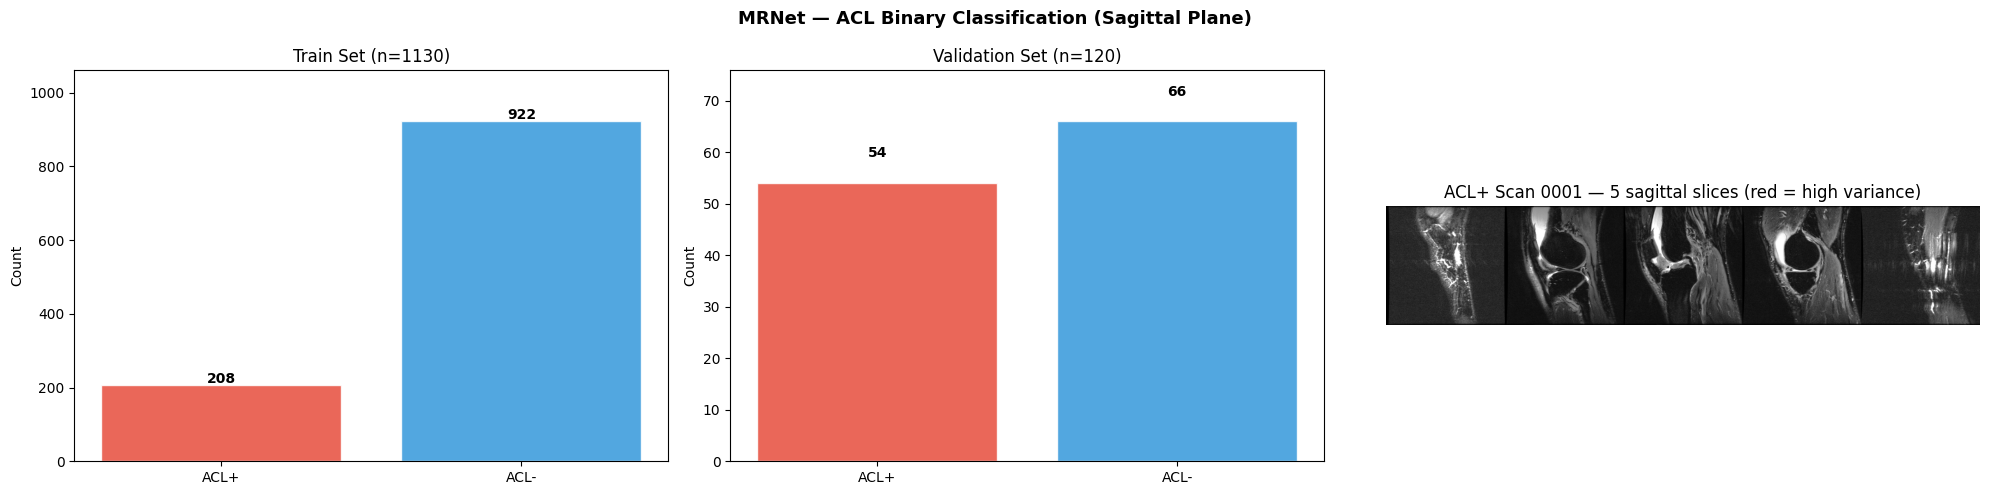


Sample volume shapes (D, H, W):
  (37, 256, 256)
  (30, 256, 256)
  (20, 256, 256)
  (33, 256, 256)
  (42, 256, 256)
  (21, 256, 256)
  (29, 256, 256)
  (38, 256, 256)
  (28, 256, 256)
  (32, 256, 256)
  (35, 256, 256)
  (36, 256, 256)
  (26, 256, 256)


In [53]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("MRNet — ACL Binary Classification (Sagittal Plane)", fontsize=13, fontweight="bold")

# Class distribution
for ax, (name, df) in zip(axes[:2], [("Train", train_df), ("Validation", valid_df)]):
    counts = [int(df["label"].sum()), int((df["label"]==0).sum())]
    bars = ax.bar(["ACL+", "ACL-"], counts, color=["#E74C3C", "#3498DB"], alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha="center", fontweight="bold")
    ax.set_title(f"{name} Set (n={len(df)})"); ax.set_ylabel("Count")
    ax.set_ylim(0, max(counts) * 1.15)

# Sample MRI slices
sample_id = train_df[train_df["label"]==1].iloc[0]["id"]
vol = np.load(str(CFG.ROOT / "train" / "sagittal" / f"{sample_id}.npy"))
D   = vol.shape[0]
var = np.var(vol.reshape(D, -1), axis=1)
topk_idx = np.sort(np.argsort(var)[-CFG.TOP_K_SLICES:])

# Show 5 evenly-spaced slices, highlight top-K
ax = axes[2]
vis_slices = np.linspace(0, D-1, 5, dtype=int)
composite = np.concatenate([vol[i] for i in vis_slices], axis=1)
ax.imshow(composite, cmap="gray")
ax.set_title(f"ACL+ Scan {sample_id} — 5 sagittal slices (red = high variance)")
ax.axis("off")

plt.tight_layout()
plt.savefig(CFG.OUT_DIR / "eda_acl.png", dpi=150, bbox_inches="tight")
plt.show()

# Volume shape stats
shapes = []
for _, row in train_df.head(20).iterrows():
    v = np.load(row["sagittal_path"], mmap_mode="r")
    shapes.append(v.shape)
print("\nSample volume shapes (D, H, W):")
for s in set(shapes):
    print(f"  {s}")